## diff ו-cumsum — נגזרת וסכום מצטבר

עכשיו עוברים מ**מבנה נתונים** ל**חשבון אינפיניטסימלי כקריאה לפונקציה** — נגזרת ואינטגרל, כשתי פעולות NumPy על מערך:

- **`np.diff(a)`** — ההפרש בין כל שני איברים סמוכים: קירוב לנגזרת. מערך באורך $n$ נותן `diff` באורך $n-1$.
- **`np.cumsum(a)`** — סכום מצטבר: קירוב לאינטגרל (הסכום ההולך וגדל). מערך באורך $n$ נותן `cumsum` **גם** באורך $n$.

```{admonition} 🎥 כאן נכנס סרטון השבוע
:class: seealso

**"נגזרת ואינטגרל: diff, cumsum, trapezoid, quad, ולולאת עדכון"** (כ-6–10 דקות, הקלטת מסך של המחברת עם קול). (הסרטון פרוש על סעיפים 9.8–9.10)

<!-- TODO (למפיק/ה): להחליף תא זה בהטמעת הסרטון בפועל, למשל:
<iframe width="100%" height="400" src="VIDEO_URL_HERE" title="שבוע 9 — נגזרת ואינטגרל: diff, cumsum, trapezoid, quad, ולולאת עדכון" frameborder="0" allowfullscreen></iframe>
-->
```

### דוגמה: מהירות מתוך מיקום, בעזרת `diff`

יש לנו את מיקום $x(t)$ של הזריקה, אבל לא נתנו לנו את הנוסחה למהירות — רק את המדידות. `np.diff` מקרב את הנגזרת: $v_x \approx \Delta x/\Delta t$.

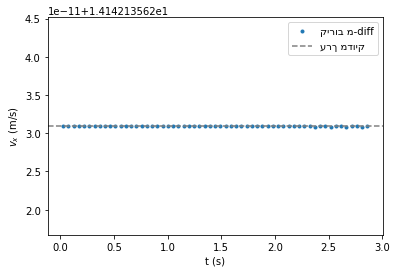

In [1]:
import numpy as np
import matplotlib.pyplot as plt

g = 9.8
theta = np.radians(45)
v0 = 20.0

t_flight = 2 * v0 * np.sin(theta) / g
t = np.linspace(0, t_flight, 60)
x = v0 * np.cos(theta) * t

dx = np.diff(x)
dt = np.diff(t)
vx_approx = dx / dt              # אורך 59, לא 60!
t_mid = (t[:-1] + t[1:]) / 2      # נקודות הזמן "בין" המדידות, כדי להתאים לאורך 59

vx_exact = v0 * np.cos(theta)     # קבועה, בלי חיכוך

fig, ax = plt.subplots()
ax.plot(t_mid, vx_approx, "o", ms=3, label="קירוב מ-diff")
ax.axhline(vx_exact, color="gray", ls="--", label="ערך מדויק")
ax.set_xlabel("t (s)")
ax.set_ylabel(r"$v_x$ (m/s)")
ax.legend()
plt.show()

### באג נפוץ: אורך `diff` קצר ב-1

`np.diff(x)` על מערך באורך 60 מחזיר מערך באורך **59** — לא 60. אם מנסים לצייר אותו ישירות מול `t` המקורי (גם באורך 60), מקבלים שגיאת אי-התאמת צורה (`ValueError`), או גרוע מזה — אם משתמשים ב-`t[:-1]` בהיסח הדעת, מקבלים ציר זמן ש"מוזז" בחצי צעד ביחס למה שהמהירות באמת מייצגת (ראו `t_mid` בדוגמה למעלה, שזה בדיוק הפתרון הנכון).

### דוגמה: מרחק כולל שהוטס, בעזרת `cumsum`

`np.cumsum` על גודל המהירות, כפול צעד הזמן, נותן קירוב למרחק המצטבר שנסע הגוף (לא רק הטווח האופקי הסופי — האורך **לאורך המסלול**).

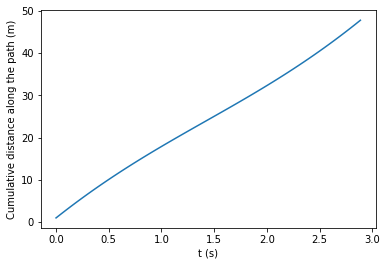

In [2]:
y = v0 * np.sin(theta) * t - 0.5 * g * t**2
vx = v0 * np.cos(theta) * np.ones_like(t)
vy = v0 * np.sin(theta) - g * t
speed = np.sqrt(vx**2 + vy**2)

dt_uniform = t[1] - t[0]
distance_traveled = np.cumsum(speed * dt_uniform)   # shape (60,) - אותו אורך כמו t

fig, ax = plt.subplots()
ax.plot(t, distance_traveled)
ax.set_xlabel("t (s)")
ax.set_ylabel("Cumulative distance along the path (m)")
plt.show()

### נסו בעצמכם

חשבו את התאוצה המקורבת $a_y\approx \Delta v_y/\Delta t$ מתוך `vy` שחושב למעלה, בעזרת `np.diff`, והשוו לערך המדויק `-g`.

In [3]:
# ay_approx = np.diff(vy) / np.diff(t)

`````{admonition} פתרון
:class: dropdown, tip
```python
ay_approx = np.diff(vy) / np.diff(t)
print(ay_approx[:5])       # אמור להיות קרוב מאוד ל- -9.8 בכל מקום
print(np.allclose(ay_approx, -g))
```
`````

### בדקו את עצמכם

In [4]:
from jupyterquiz import display_quiz

questions = [
    {
        "question": "אם <code>a</code> באורך 100, מה אורך <code>np.diff(a)</code>?",
        "type": "multiple_choice",
        "answers": [
            {"answer": "99", "correct": True, "feedback": "נכון — יש 99 הפרשים בין 100 איברים סמוכים."},
            {"answer": "100", "correct": False, "feedback": "לא — diff מקצר את המערך באחד."},
            {"answer": "101", "correct": False, "feedback": "לא נכון."},
            {"answer": "50", "correct": False, "feedback": "לא — diff מקצר את המערך רק באחד, לא בחצי."}
        ]
    },
    {
        "question": "מה אורך <code>np.cumsum(a)</code> עבור <code>a</code> באורך 100?",
        "type": "multiple_choice",
        "answers": [
            {"answer": "99, כמו diff", "correct": False, "feedback": "לא — cumsum לא מקצר את המערך."},
            {"answer": "100 - אותו אורך כמו a", "correct": True, "feedback": "נכון — לכל איבר יש סכום מצטבר עד אותו מקום."},
            {"answer": "1 - רק הסכום הסופי", "correct": False, "feedback": "זה מה ש-np.sum (בלי cum) מחזיר, לא cumsum."},
            {"answer": "101", "correct": False, "feedback": "לא — cumsum לא מוסיף איברים; האורך נשאר בדיוק כמו של a."}
        ]
    }
]
display_quiz(questions)

<IPython.core.display.Javascript object>

### תרגול עצמי

חשבו מהו הטווח האופקי הכולל בעזרת `np.cumsum` על `vx` (כפול `dt_uniform`), והשוו לערך התיאורטי $R=v_0^2\sin(2\theta)/g$.

In [5]:
# x_cumsum = np.cumsum(vx * dt_uniform)
# ...

`````{admonition} פתרון
:class: dropdown, tip
```python
x_cumsum = np.cumsum(vx * dt_uniform)
R_theory = v0**2 * np.sin(2 * theta) / g

print("קירוב cumsum:", x_cumsum[-1])
print("תיאוריה:", R_theory)
```
`````